<a href="https://colab.research.google.com/github/cepulmano/ai-healthcare-medicine/blob/main/day4/COVID_19_Daily_Case_Prediction_Using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Daily Case Prediction Using LSTM

## Import packages and the dataset

The dataset used in the activity is the COVID-19 linelist of positive cases in the Philippines. Each row in the data pertains to one positive case of COVID-19, confirmed through laboratory testing.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load actual COVID-19 data from CSV and aggregate daily counts ---
raw_data = pd.read_csv('https://raw.githubusercontent.com/cepulmano/msys116-covid-modeling/refs/heads/master/covidtracker.csv')
raw_data.head()

,Case_Number,Reporting_Facility,Age,Age_Group,Sex,Repatriate,Region,Province,CityMunicipality,Barangay,...,DateRepRem,regionPSGC,provincePSGC,cityPSGC,barangayPSGC,imputed_Date_Onset,imputed_Date_Admitted,imputed_Date_Specimen,imputed_Date_Recovered,DOH_Imputed_Date_Onset
0,FGCQR0TA,ST. LUKE'S MEDICAL CENTER-GLOBAL CITY,35.0,30 - 39 y/o,MALE,NaN,NCR,NCR,TAGUIG CITY,NaN,...,2020-06-06,130000000.0,137600000.0,137607000.0,NaN,NaN,NaN,NaN,NaN,2020-04-19
1,79OZUVZJ,OTHER REPORTING UNIT,26.0,20 - 29 y/o,MALE,NaN,05,ALBAY,LEGAZPI CITY (CAPITAL),NaN,...,2020-07-13,50000000.0,50500000.0,50506000.0,NaN,NaN,NaN,NaN,NaN,2020-05-13
2,VS0GFMDG,OTHER REPORTING UNIT,71.0,70 - 79 y/o,MALE,NaN,NCR,NCR,CITY OF MUNTINLUPA,NaN,...,2020-07-13,130000000.0,137600000.0,137603000.0,NaN,NaN,NaN,NaN,NaN,2020-05-09
3,AUUGLG53,OTHER REPORTING UNIT,57.0,50 - 59 y/o,MALE,NaN,NCR,NaN,NaN,NaN,...,2020-07-13,130000000.0,131000000.0,NaN,NaN,NaN,NaN,NaN,NaN,2020-05-14
4,XN7PXPZL,OTHER REPORTING UNIT,33.0,30 - 39 y/o,MALE,NaN,NCR,NaN,NaN,NaN,...,2020-07-13,130000000.0,131000000.0,NaN,NaN,NaN,NaN,NaN,NaN,2020-05-09


## Aggregate the data to get the number of daily cases based on the date of reporting

Actual Data Head (after aggregation):
             Cases
Report_Date       
2020-04-01     226
2020-04-02     317
2020-04-03     381
2020-04-04      72
2020-04-05     150

Actual Data Description (after aggregation):
            Cases
count   61.000000
mean   242.131148
std    121.268088
min     72.000000
25%    178.000000
50%    216.000000
75%    280.000000
max    789.000000


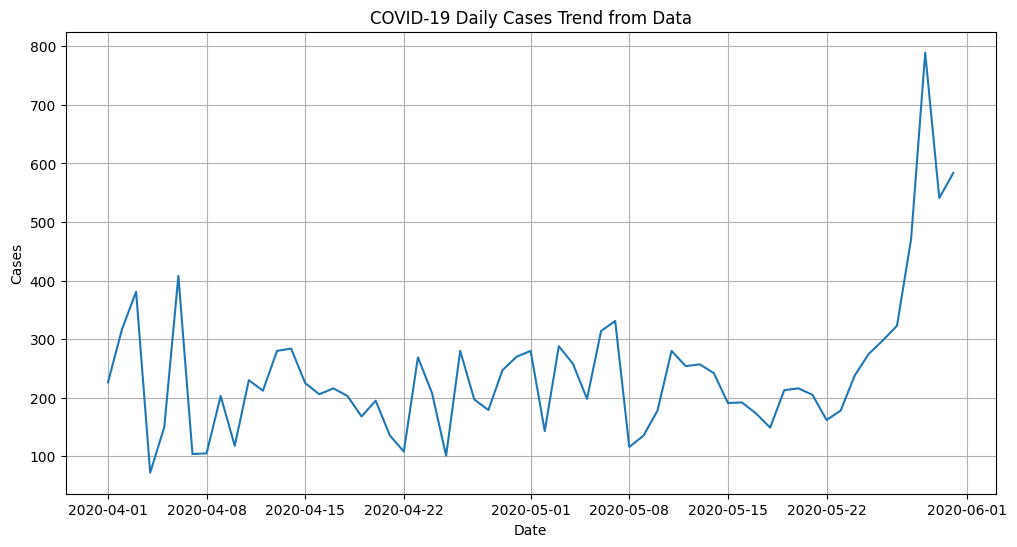

In [ ]:
date_field = "Report_Date"

# Attempt to parse common date column names and set as index
raw_data[date_field] = pd.to_datetime(raw_data[date_field], errors='coerce')
raw_data = raw_data.dropna(subset=[date_field])
raw_data = raw_data.set_index(date_field)

# Group by the date index and count the number of cases per day
# Each row is a case, so counting rows per day gives daily cases
data = raw_data.groupby(raw_data.index).size().reset_index(name='Cases')
data = data.set_index(date_field) # Set the date back as index after aggregation

# Ensure data is sorted by date
data = data.sort_index()

print("Actual Data Head (after aggregation):")
print(data.head())
print("\nActual Data Description (after aggregation):")
print(data.describe())

plt.figure(figsize=(12, 6))
plt.plot(data['Cases'])
plt.title('COVID-19 Daily Cases Trend from Data')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.grid(True)
plt.show()

## Smoothen the data by applying a 7-day moving average

Applying 7-day moving average to 'Cases' data...
Data head after smoothing:
             Cases  Cases_Smoothed
Report_Date                       
2020-04-01     226      236.857143
2020-04-02     317      236.857143
2020-04-03     381      236.857143
2020-04-04      72      236.857143
2020-04-05     150      236.857143


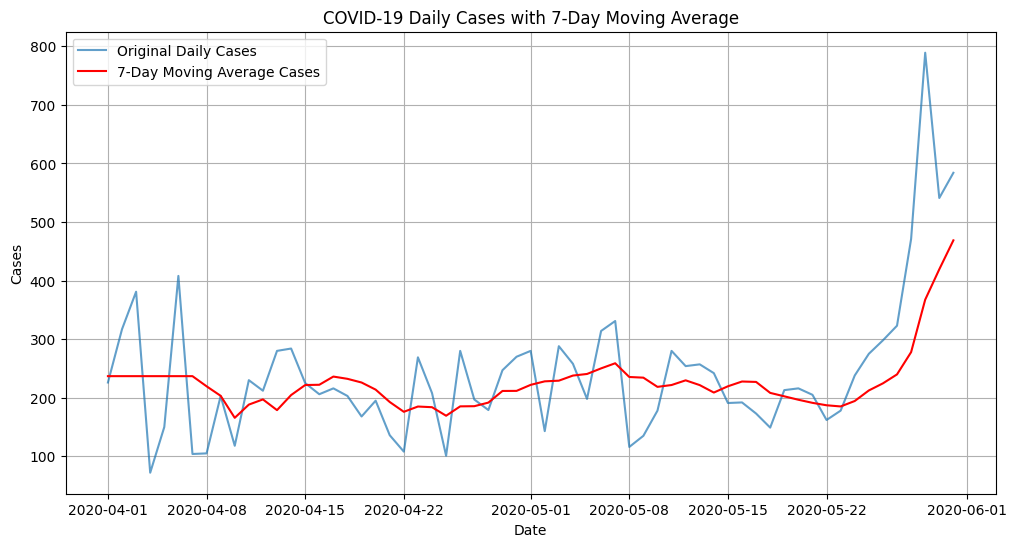

In [ ]:
print("Applying 7-day moving average to 'Cases' data...")
# Apply 7-day moving average
data['Cases_Smoothed'] = data['Cases'].rolling(window=7, center=False).mean()

# Fill NaN values created by the rolling window (e.g., first 3 and last 3 days)
# Using forward fill then backward fill to handle both ends if data is long enough
data['Cases_Smoothed'] = data['Cases_Smoothed'].ffill().bfill()

# Replace the original 'Cases' with the smoothed version for further processing
# data['Cases'] = data['Cases_Smoothed']

print("Data head after smoothing:")
print(data.head())

# Optional: Plot original vs smoothed data to visualize the effect
plt.figure(figsize=(12, 6))
# We need to use 'raw_data' from the initial load to get the truly original counts
plt.plot(data.index, data['Cases'], label='Original Daily Cases', alpha=0.7)
plt.plot(data.index, data['Cases_Smoothed'], label='7-Day Moving Average Cases', color='red')
plt.title('COVID-19 Daily Cases with 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.grid(True)
plt.show()

## Normalizing the data and creating the train and test splits

In [ ]:
# Preprocessing Data
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data['Cases_Smoothed'].values.reshape(-1, 1))

# Define time step for LSTM (how many previous days to use to predict the next day)
TIME_STEP = 10 # Using the past 10 days to predict the next day

def create_sequences(data, time_step):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Train on first 30 days of original data
TRAIN_DATA_POINTS_RAW = 30

# Create training sequences from the first TRAIN_DATA_POINTS_RAW of the original scaled data
# The targets for these sequences will range from index TIME_STEP to TRAIN_DATA_POINTS_RAW - 1
train_scaled_segment = scaled_data[:TRAIN_DATA_POINTS_RAW]
X_train, y_train = create_sequences(train_scaled_segment, TIME_STEP)

# Create testing sequences from the rest of the data
# The test segment needs to start TIME_STEP days before the first prediction point
# The first prediction should be for the day after TRAIN_DATA_POINTS_RAW
test_scaled_segment = scaled_data[TRAIN_DATA_POINTS_RAW - TIME_STEP:]
X_test, y_test = create_sequences(test_scaled_segment, TIME_STEP)
# Filter y_test to only include targets beyond TRAIN_DATA_POINTS_RAW
# The sequences created from test_scaled_segment start predicting from index TRAIN_DATA_POINTS_RAW
# in the original scaled_data
y_test_start_idx_in_scaled_data = TRAIN_DATA_POINTS_RAW
y_test_indices = np.arange(y_test_start_idx_in_scaled_data, len(scaled_data))

# Reshape X for LSTM input (samples, time_steps, features)
# X_train and X_test might already be shaped correctly by create_sequences, but reshape explicitly to be safe
if X_train.size > 0:
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
if X_test.size > 0:
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"\nTraining X shape: {X_train.shape}")
print(f"Training y shape: {y_train.shape}")
print(f"Testing X shape: {X_test.shape}")
print(f"Testing y shape: {y_test.shape}")


Training X shape: (20, 10, 1)
Training y shape: (20,)
Testing X shape: (31, 10, 1)
Testing y shape: (31,)


## Building the LSTM model and training

LSTM networks operate similarly to RNNs but include specialized mechanisms called gates: Forget gate, input gate, and output gate. These gates regulate how information flows through the network, allowing it to retain important information over extended periods. The forget gate decides which past information to discard, the input gate controls the relevance of new information, and the output gate manages what information the LSTM unit should pass to the next timestamp.  [source](https://dida.do/what-is-an-lstm-neural-network)

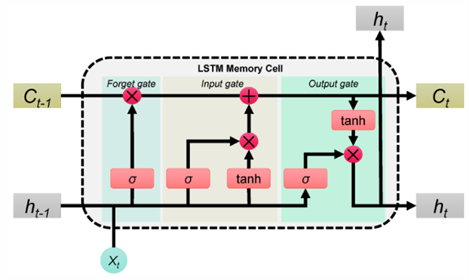

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.0160
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 0.0125
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0095
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0075
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0052
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0052
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0054
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0072
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0068
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - loss: 0.0063
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.0061
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.0052
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.0051
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0049
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0049
Epoch 16/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

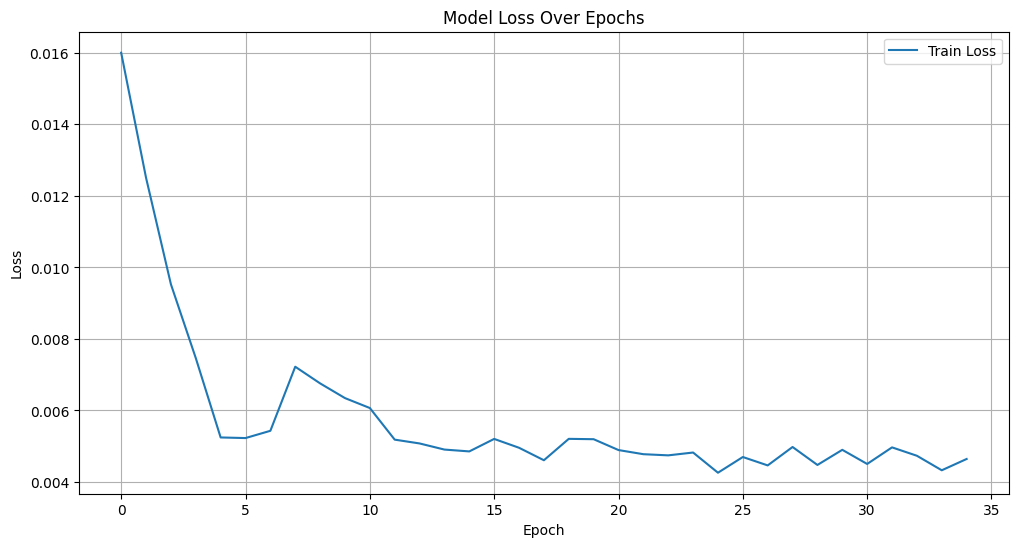

In [ ]:
# Build LSTM Model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(TIME_STEP, 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

# Compile and Train Model
model.compile(optimizer='adam', loss='mean_squared_error')

# Use EarlyStopping to prevent overfitting
early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True) # Monitor 'loss' since 'val_loss' might not be available without validation_split

history = model.fit(X_train, y_train, epochs=50, batch_size=32, callbacks=[early_stopping], verbose=1)

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Evaluating the performance of the model using Mean-Squared Error (MSE)

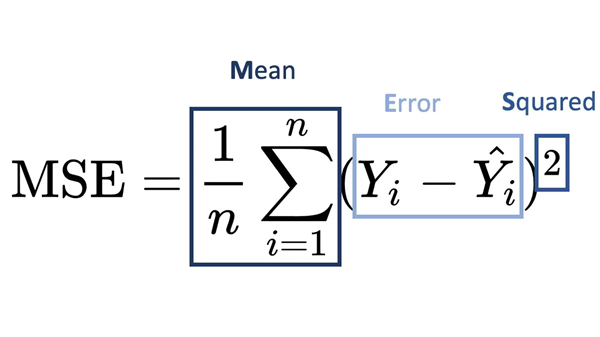


Test Loss: 0.0602
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


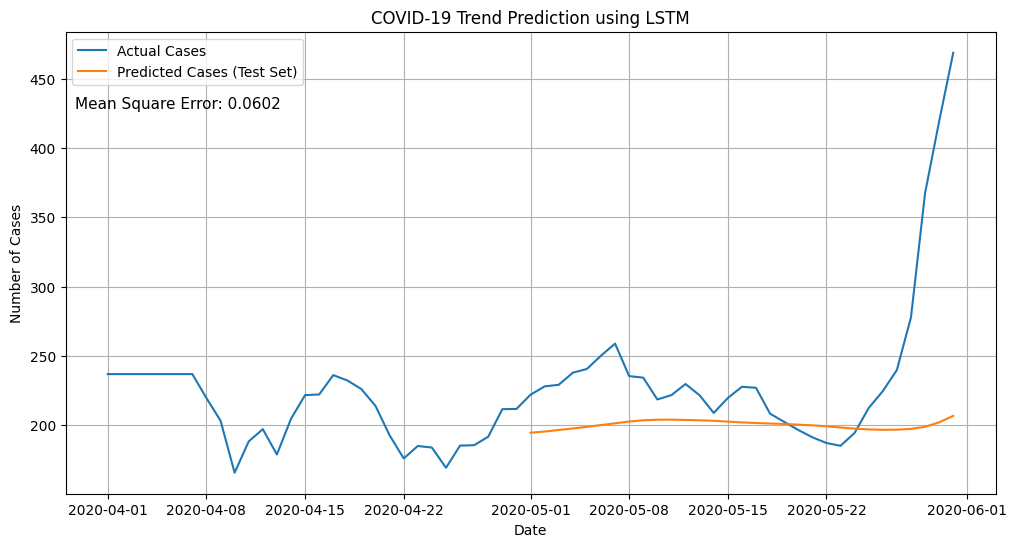

In [ ]:
# Make Predictions
# Evaluate the model on the test set
if X_test.size > 0:
    loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Loss: {loss:.4f}")

    # Make predictions on the test set
    predictions = model.predict(X_test)

    # Inverse transform the predictions to get actual scale
    predictions = scaler.inverse_transform(predictions)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
else:
    print("No test data to make predictions.")
    predictions = np.array([])
    y_test_actual = np.array([])

# Visualize Results

# Calculate the starting index in the original 'data' DataFrame for the predictions
# The first prediction target (y_test[0]) corresponds to data.index[TRAIN_DATA_POINTS_RAW]
prediction_start_index_in_data = TRAIN_DATA_POINTS_RAW

# Create a DataFrame for actual and predicted values
plot_data = data.copy()
plot_data['Predictions'] = np.nan

# Assign predictions to the correct slice of plot_data.
# The predictions should align starting from data.index[TRAIN_DATA_POINTS_RAW]
if predictions.size > 0 and prediction_start_index_in_data < len(plot_data):
    # Calculate the end index for predictions in plot_data
    prediction_end_index_in_data = prediction_start_index_in_data + len(predictions)
    plot_data.iloc[prediction_start_index_in_data : prediction_end_index_in_data, plot_data.columns.get_loc('Predictions')] = predictions.flatten()

plt.figure(figsize=(12, 6))
plt.text(0.01, 0.86, f'Mean Square Error: {loss:.4f}', transform=plt.gca().transAxes, fontsize=11, verticalalignment='top')
plt.plot(data.index, data['Cases_Smoothed'], label='Actual Cases')
plt.plot(plot_data.index, plot_data['Predictions'], label='Predicted Cases (Test Set)')
plt.title('COVID-19 Trend Prediction using LSTM')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid(True)
plt.show()

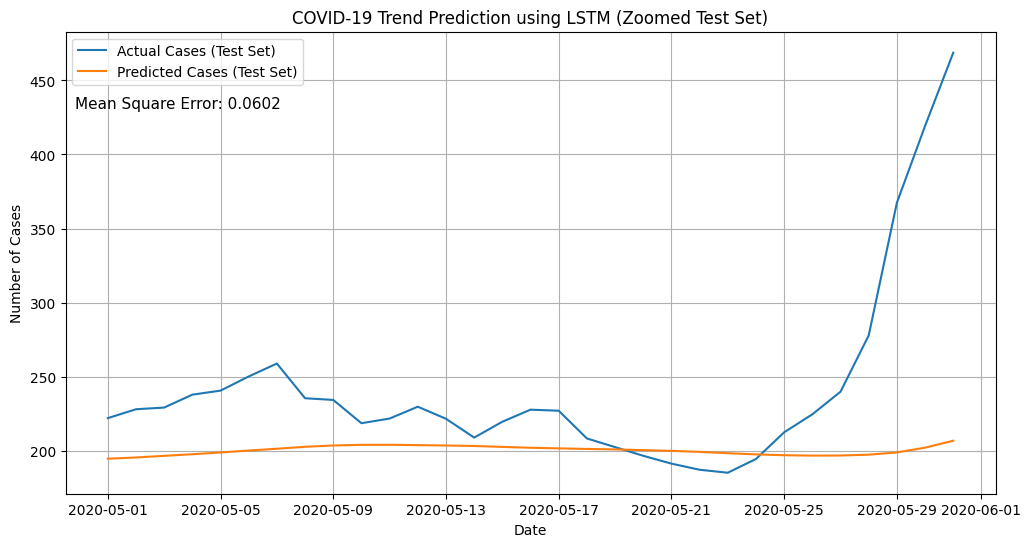


Model training and prediction complete.


In [ ]:
# Zoom in on the prediction part
plt.figure(figsize=(12, 6))
if prediction_start_index_in_data < len(data):
    plt.plot(data.index[prediction_start_index_in_data:], data['Cases_Smoothed'][prediction_start_index_in_data:], label='Actual Cases (Test Set)')
    plt.plot(plot_data.index[prediction_start_index_in_data:], plot_data['Predictions'][prediction_start_index_in_data:], label='Predicted Cases (Test Set)')
    plt.text(0.01, 0.86, f'Mean Square Error: {loss:.4f}', transform=plt.gca().transAxes, fontsize=11, verticalalignment='top')
else:
    print("No data available to plot zoomed test set, as prediction start index is beyond data length.")

plt.title('COVID-19 Trend Prediction using LSTM (Zoomed Test Set)')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid(True)
plt.show()

print("\nModel training and prediction complete.")